# Report for Time Series Prediction

The aim of the challenge is to train a time series model that can predict the expected number of service requests for each area for the 4 weeks following the end of recorded time period.

First let's import some libraries, load the data and count the number of weekly requests.

### Import libraries

In [21]:
import csv
from collections import defaultdict
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

### Load the CSV file containing the requests data

In [2]:
filename = "sr_hex.csv"
with open(filename) as fp:
    reader = csv.reader(fp, delimiter=",", quotechar='"')
    # next(reader, None)  # skip the headers
    data_read = [row for row in reader]

hex_dict = defaultdict(list)
for req in data_read[1:]:
    hex_dict[req[-1]].append(req)

print(data_read[0])

['notification_number', 'reference_number', 'creation_timestamp', 'completion_timestamp', 'directorate', 'department', 'branch', 'section', 'code_group', 'code', 'cause_code_group', 'cause_code', 'official_suburb', 'latitude', 'longitude', 'h3_level8_index']


### Count the weekly requests and store in a dictionary

In [59]:
format_string = "%Y-%m-%d %H:%M:%S"
all_counts = defaultdict(lambda: [0] * 51)
weekly_counts = {}
startdate = datetime(2020,1,5,0,0,0)
date_idxs = {}
for d in range(51): date_idxs[startdate + d*timedelta(days=7)] = d

for hex_key, reqs in hex_dict.items():
    for req in reqs:
        req_dt = datetime.strptime(req[2][:-6], format_string)
        week_offset = (req_dt - startdate).days // 7
        if week_offset < 0 or week_offset >= 51: continue
        all_counts[hex_key][date_idxs[startdate + week_offset*timedelta(days=7)]] += 1

    # Filter areas with low requests
    if len(np.nonzero(all_counts[hex_key])[0]) > 26:
        weekly_counts[hex_key] = all_counts[hex_key]

### Initial Analysis
Let's view the statistics of the dataset and make a few plots.

In [60]:
number_of_time_series = len(weekly_counts)
print(f"Number of time series' to use for training: {number_of_time_series}")

Number of time series' to use for training: 1281


['88ad368737fffff' '88ad368581fffff' '88ad361169fffff' '88ad3695ebfffff'
 '88ad36026bfffff']


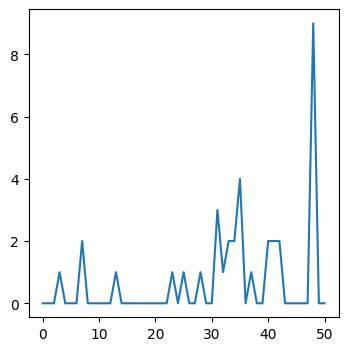

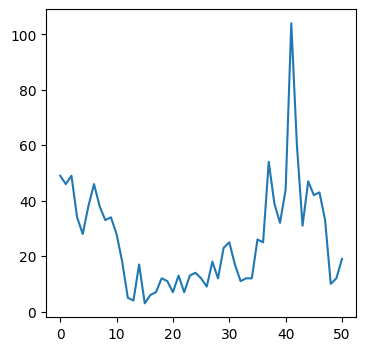

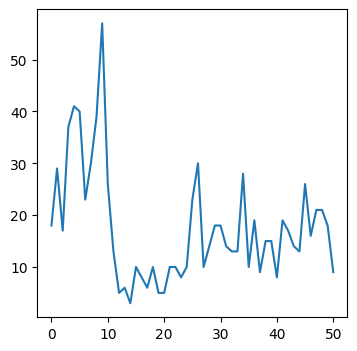

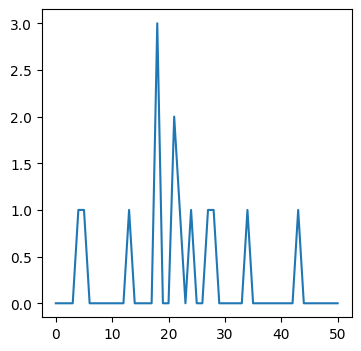

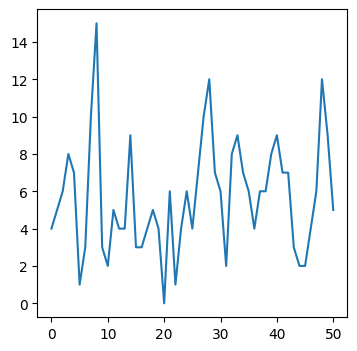

In [7]:
hex_keys = np.random.choice(list(weekly_counts.keys()), 5)
print(hex_keys)

for hex_key in hex_keys:
    plt.figure(figsize=(4, 4))
    plt.plot(weekly_counts[hex_key])
    plt.show()

### Initial analysis
Visual inspection indicates that the expected number of requests are very noisy and thus difficult to predict accurately.
After careful consideration I concluded that the best option is to predict a single linear function representing the target 4 weeks instead of predicting 4 distinct values. This can be done by fitting target functions using the last TARGET_FIT_LEN number of weeks' data and then training a model to predict the fitted target function's slope and bias. The model receives the past SEQ_LEN number of weeks' data and can thus be trained using multiple reference weeks for a single area.

# Solution Implementation
I decided to train a fully-connected neural network for this task. The network receives as input the total number of weekly requests for the past 26 weeks, then predicts the slope and bias of a linear function representing the subsequent 4 weeks. For the hyper-parameter `TARGET_FIT_LEN` the following values were tested: `10, 20, 30`. It was decided to set `TARGET_FIT_LEN=10` to reduce the influence of the number of old requests since the number of requests tend to fluctuate significantly throughout the year.

### DEFINE ARGUMENTS

In [73]:
TARGET_FIT_LEN = 10
SEQ_LEN = 26
BATCH_SIZE = 64
LR = 1e-4
DEVICE = "cpu"
STORE_WEIGHTS = True
NUM_TRAINING_SAMPLES = 1000

### Setup Dataset

In [74]:
class TimeSeriesDataset(torch.utils.data.Dataset):
    def __init__(self, hex_keys, weekly_counts, target_fit_len=TARGET_FIT_LEN):
        self.seq_len = SEQ_LEN
        self.hex_keys = hex_keys
        self.weekly_counts = weekly_counts # num_hexs, num_weeks

        self.target_fit_len = target_fit_len

    def __len__(self):
        return len(self.hex_keys)

    def __getitem__(self, index):
        seq_idx = np.random.randint(51 - (self.seq_len + 4))
        input_seq = []
        target_seq = self.weekly_counts[self.hex_keys[index]][seq_idx+self.seq_len+4 - self.target_fit_len: seq_idx+self.seq_len+4]
        slope, bias = np.polyfit(np.arange(self.target_fit_len), np.array(target_seq), 1)

        input_seq = self.weekly_counts[self.hex_keys[index]][seq_idx: seq_idx+self.seq_len]
                    
        return torch.tensor(input_seq).float(), torch.tensor([slope, (self.target_fit_len - 4)*slope + bias]).float()

### Setup model

In [63]:
class RequestPredictor(nn.Module):
    def __init__(self):
        super(RequestPredictor, self).__init__()

        self.net = nn.Sequential(nn.Linear(26, 128), nn.SiLU(), nn.Linear(128, 2))

    def forward(self, x):
        return self.net(x)

### Initialize model, dataloaders and optimizer

In [64]:
hex_keys = list(weekly_counts.keys())
np.random.shuffle(hex_keys)

training_set = TimeSeriesDataset(hex_keys[:NUM_TRAINING_SAMPLES], weekly_counts)
trainloader = torch.utils.data.DataLoader(training_set, batch_size=BATCH_SIZE, shuffle=True)

validation_set = TimeSeriesDataset(hex_keys[NUM_TRAINING_SAMPLES:], weekly_counts)
valloader = torch.utils.data.DataLoader(validation_set, batch_size=BATCH_SIZE, shuffle=True)

predictor = RequestPredictor()
predictor.to(DEVICE)

optimizer = torch.optim.Adam(params=predictor.parameters(), lr=LR)

### Train loop

In [65]:
train_iter, val_iter = 0, 0
losses, slope_diffs, bias_diffs = [], [], []
if STORE_WEIGHTS and not os.path.exists("weights"): os.mkdir("weights")

for epoch in range(50):
    elosses, eslope_diffs, ebias_diffs = [], [], []
    for item in trainloader:
        optimizer.zero_grad()

        train_iter += 1
        request_batch, target_batch = item
        request_batch = request_batch.to(DEVICE)
        target_batch = target_batch.to(DEVICE)

        result = predictor(request_batch) # bs, 2
        loss = F.mse_loss(result, target_batch, reduction="mean")
        loss.backward()

        optimizer.step()

        with torch.no_grad():
            slope_diff = (result[:,0] - target_batch[:,0]).abs().mean()
            bias_diff = (result[:,1] - target_batch[:,1]).abs().mean()

        if train_iter % 100 == 1:
            print(f"Epoch: {epoch}, Train Iter: {train_iter}, Loss: {loss:.2f}, Slope diff: {slope_diff:.2f}, Bias diff: {bias_diff:.2f}")

    for item in valloader:
        with torch.no_grad():
            val_iter += 1
            request_batch, target_batch = item
            request_batch = request_batch.to(DEVICE) # bs,9,c,h,w
            target_batch = target_batch.to(DEVICE) # bs

            result = predictor(request_batch) # bs
            loss = F.mse_loss(result, target_batch, reduction="mean")

            slope_diff = (result[:,0] - target_batch[:,0]).abs().mean()
            bias_diff = (result[:,1] - target_batch[:,1]).abs().mean()

            elosses.append(float(loss))
            eslope_diffs.append(float(slope_diff))
            ebias_diffs.append(float(bias_diff))

            if val_iter % 100 == 1:
                print(f"Val Iter: {val_iter}, Loss: {loss:.2f}, Slope diff: {slope_diff:.2f}, Bias diff: {bias_diff:.2f}")

    losses.append(sum(elosses)/len(elosses))
    slope_diffs.append(sum(eslope_diffs)/len(eslope_diffs))
    bias_diffs.append(sum(ebias_diffs)/len(ebias_diffs))
    
    if epoch % 10 == 0 and STORE_WEIGHTS:
        torch.save(predictor.state_dict(),f"weights/time_series_{epoch}.pt")

Epoch: 0, Train Iter: 1, Loss: 203.34, Slope diff: 1.34, Bias diff: 14.54
Val Iter: 1, Loss: 207650.58, Slope diff: 3.35, Bias diff: 93.04
Epoch: 6, Train Iter: 101, Loss: 32.65, Slope diff: 1.53, Bias diff: 4.97
Epoch: 12, Train Iter: 201, Loss: 16.28, Slope diff: 0.89, Bias diff: 3.01
Epoch: 18, Train Iter: 301, Loss: 5.74, Slope diff: 0.94, Bias diff: 2.19
Val Iter: 101, Loss: 7.05, Slope diff: 0.79, Bias diff: 2.41
Epoch: 25, Train Iter: 401, Loss: 8.14, Slope diff: 0.72, Bias diff: 2.26
Epoch: 31, Train Iter: 501, Loss: 10.86, Slope diff: 0.76, Bias diff: 2.38
Epoch: 37, Train Iter: 601, Loss: 4.05, Slope diff: 0.75, Bias diff: 1.54
Val Iter: 201, Loss: 4.68, Slope diff: 0.85, Bias diff: 1.90
Epoch: 43, Train Iter: 701, Loss: 5.23, Slope diff: 0.70, Bias diff: 1.80


### Plot results

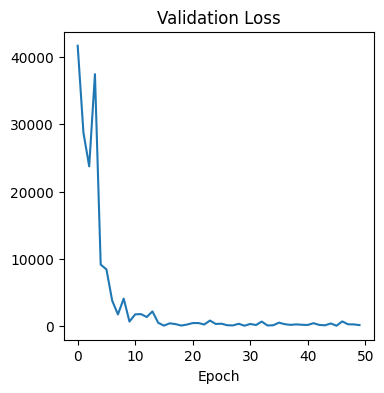

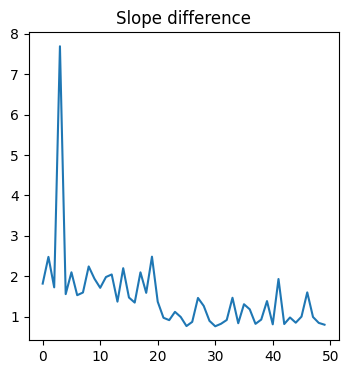

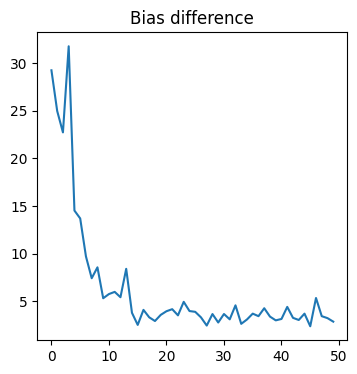

In [66]:
plt.figure(figsize=(4, 4))
plt.plot(losses)
plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.show()
plt.figure(figsize=(4, 4))
plt.plot(slope_diffs)
plt.title("Slope difference")
plt.show()
plt.figure(figsize=(4, 4))
plt.plot(bias_diffs)
plt.title("Bias difference")
plt.show()

# Evaluate Predictor

Let's plot a few graphs to visualize the predictions.

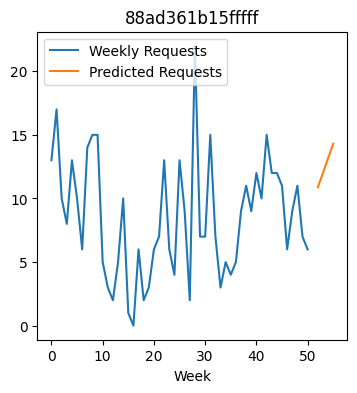

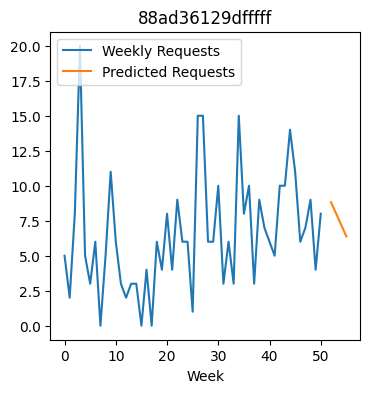

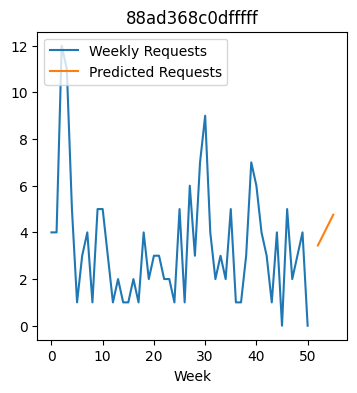

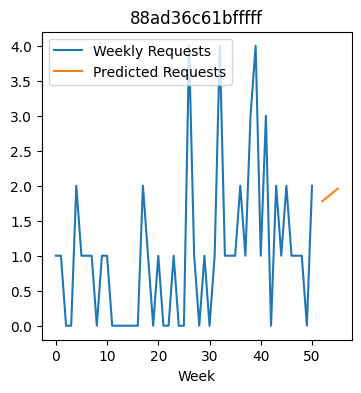

In [72]:
sample_hex_keys = np.random.choice(hex_keys[NUM_TRAINING_SAMPLES:], 4)
for hex_key in sample_hex_keys:
    predicted_function = predictor(torch.tensor(weekly_counts[hex_key][-SEQ_LEN:]).float())
    slope, bias = float(predicted_function[0]), float(predicted_function[1])
    x = list(range(51))
    
    plt.figure(figsize=(4, 4))
    plt.plot(x, weekly_counts[hex_key], label="Weekly Requests")
    plt.plot([52, 53, 54, 55], [bias, slope*1 + bias, slope*2 + bias, slope*3 + bias], label="Predicted Requests")
    plt.legend(loc="upper left")
    plt.title(hex_key)
    plt.xlabel("Week")
    plt.show()